Alexander W. Criswell 11/21/25

Testing the spectral chain plots

In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
import numpy as np
import cupy as xp
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoLocator
from matplotlib.pyplot import cycler
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.collections import LineCollection
import matplotlib.cm
from matplotlib import patches
# import jax.numpy as jnp
# import jax; jax.config.update("jax_enable_x64", True)
from corner import corner, overplot_lines
import legwork as lw
import astropy.units as u
from tqdm import tqdm
from math import factorial
import scipy.stats as scst
import scipy.special as sc
import pickle

In [3]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State, BranchSupplemental
from eryn.backends import SupplementalBackend
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.utils import TransformContainer
from eryn.moves import GaussianMove, StretchMove, CombineMove, DistributionGenerate, MTDistGenMove, Move
from eryn.utils.utility import groups_from_inds
from multiprocessing import Pool

In [4]:
np.random.seed(42)

In [5]:
xp.cuda.is_available()

True

In [6]:
## set environment variables
import os
os.environ['PELARGIR_GPU'] = '1'
os.environ['SCIPY_ARRAY_API'] = '1'
os.environ['PELARGIR_ERYN'] = '1'

In [7]:
if os.environ['PELARGIR_GPU']:
    print('GPU enabled.')

GPU enabled.


In [8]:
import sys
prop_path = '/home/awc/Documents/LISA/projects/lisa_population_inference/pelargir-gb/pelargir/'
sys.path.insert(1, prop_path)
from models import PopModel
from inference import GalacticBinaryPrior, PopulationHyperPrior
from utils import get_amp_freq, lisa_noise_psd, set_style, to_numpy
from plotting import plot_spectra, plot_spectra_flexible, plot_corners, plot_model_chains, plot_spectra_chains, plot_model_loglikes, plot_Nres_hist
from moves import make_PriorMove, PoissonMove
import distributions as st

GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.


In [9]:
specchain = np.load('/home/awc/Documents/LISA/projects/lisa_population_inference/pelargir-gb/results/test_runs/18-tr/run/chains/spec_chain_200.npy')

In [10]:
specchain.shape

(200, 4, 1, 1, 94, 10, 1)

In [13]:
t0_sc = specchain[:,0,...].squeeze()

In [14]:
t0_sc.shape

(200, 94, 10)

In [16]:
with open('/home/awc/Documents/LISA/projects/lisa_population_inference/pelargir-gb/results/test_runs/19-tr/data/dataset.pickle','rb') as f:
    datadict = pickle.load(f)

In [39]:
set_style()

In [130]:
from matplotlib.lines import Line2D
def test_plot_spectra_chains(chain,datadict,xlim=None,ylim=None):
    
    ## get data spectra
    fs = to_numpy(datadict['fs'])
    sim_noise_psd = to_numpy(lisa_noise_psd(datadict['fs']))
    sim_spec = to_numpy(datadict['fg']) + sim_noise_psd
    sigma = to_numpy(datadict['fg_sigma'])
        
    Nf = len(fs)
    spec_chain = chain
    
    ## plot
    plt.figure(figsize=(7,4))
    
    spec_chain_color = 'slategrey'
    spec_chain_lw = 1
    spec_chain_alpha = 0.01

    ## set dims for iteration and plotting
    ## because reshape breaks things for some reason
    ## this will break for nwalkers>1 but I'll fix it later
    dims = np.argwhere(np.array(specchain.squeeze().shape) != Nf).flatten()
    Ni, Nj = np.array(specchain.squeeze().shape)[dims]
    for i in range(spec_chain.shape[Ni]):
        for j in range(spec_chain.shape[Nj]):
            plt.loglog(datadict['fs'].get(),sim_noise_psd+spec_chain[i,:,j],
                       alpha=spec_chain_alpha,c=spec_chain_color,
                       linewidth=spec_chain_lw,label='__nolabel__')
    
    plt.loglog(fs,sim_noise_psd,c='k',ls='--',label='noise')

    plt.fill_between(fs,10**(np.log10(sim_spec)-2*sigma),10**(np.log10(sim_spec)+2*sigma),
                     color='turquoise',alpha=0.5,label=r'PSD 2$\sigma$ Uncertainty',zorder=-10)
    plt.loglog(fs,sim_spec,label='Total Simulated PSD',c='teal')
    
    # adding custom legend entry
    handles, labels = plt.gca().get_legend_handles_labels()
    spec_line_handle = Line2D([0], [0], label='Spectral Posterior Draws', color=spec_chain_color, alpha=spec_chain_alpha, linewidth=spec_chain_lw)
    handles.extend([spec_line_handle])
    
    plt.legend(loc='upper right')
    plt.xlabel('f [Hz]')
    plt.ylabel('PSD [Hz^-1]')
    if xlim is not None:
        plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.show()
    
    return


In [115]:
t0_sc.shape

(200, 94, 10)

In [102]:
np.argwhere(np.array(t0_sc.shape) != 94).flatten()

array([0, 2])

In [96]:
t0_r0_sc = t0_sc[:,:,0]
t0_r0_sc.shape

(200, 94)

In [46]:
t0_sc_rs = t0_sc.reshape(94,-1)
t0_sc_rs.shape

(94, 2000)

In [111]:
thinned = t0_sc[::10,:,:]

In [112]:
thinned.shape

(20, 94, 10)

In [121]:
Nf = 94
dims = np.argwhere(np.array(specchain.squeeze().shape) != Nf).flatten()
dims, np.array(specchain.squeeze().shape)[dims]

(array([0, 1, 3]), array([200,   4,  10]))

In [123]:
specchain.squeeze()[dims].shape

(3, 4, 94, 10)

In [ ]:
for idx in np.npindex(specchain.squeeze()[dims])

In [132]:
 np.argwhere(np.array(specchain.shape) != 94).flatten()

array([0, 1, 2, 3, 5, 6])

0 2


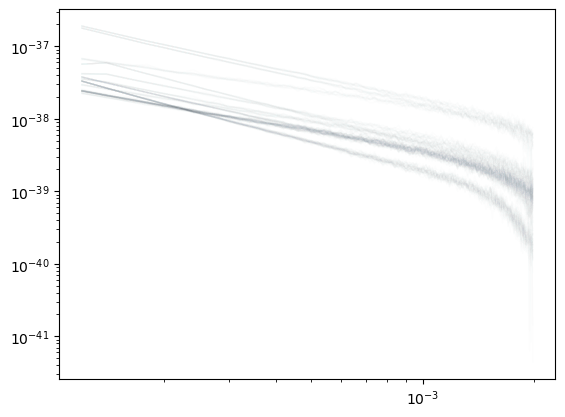

In [113]:
plt.figure()

Ni,Nj = np.argwhere(np.array(specchain.shape) != 94).flatten()
print(Ni,Nj)
for i in range(thinned.shape[Ni]):
    for j in range(thinned.shape[Nj]):
        plt.loglog(datadict['fs'].get(),thinned[i,:,j],color='slategrey',alpha=0.01,lw=1)
# plt.loglog(datadict['fs'].get(),t0_r0_sc.T)
plt.show()

ValueError: x and y can be no greater than 2D, but have shapes (94,) and (94, 200, 4, 10)

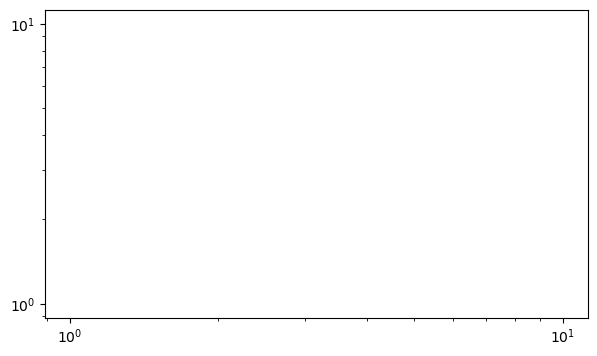

In [131]:
rs = specchain.squeeze().reshape((94,*np.array(specchain.squeeze().shape)[dims]))
test_plot_spectra_chains(rs,datadict,xlim=(5e-4,),ylim=(1e-40,1e-36))

In [66]:
tarr = np.arange(100)
yarrs = np.zeros((20,100))
yarrs[:,:] = tarr

In [68]:
yarrs = yarrs * np.arange(20)[:,None]

In [69]:
yarrs

array([[0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [0.000e+00, 1.000e+00, 2.000e+00, ..., 9.700e+01, 9.800e+01,
        9.900e+01],
       [0.000e+00, 2.000e+00, 4.000e+00, ..., 1.940e+02, 1.960e+02,
        1.980e+02],
       ...,
       [0.000e+00, 1.700e+01, 3.400e+01, ..., 1.649e+03, 1.666e+03,
        1.683e+03],
       [0.000e+00, 1.800e+01, 3.600e+01, ..., 1.746e+03, 1.764e+03,
        1.782e+03],
       [0.000e+00, 1.900e+01, 3.800e+01, ..., 1.843e+03, 1.862e+03,
        1.881e+03]])

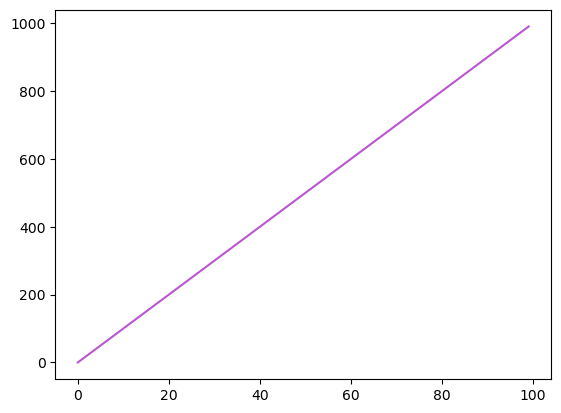

In [71]:
plt.figure()
plt.plot(tarr,yarrs[10,:])
plt.show()

In [79]:
tarr.shape,yarrs.shape

((100,), (20, 100))

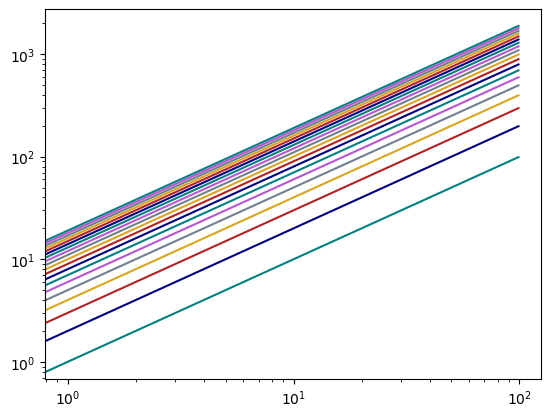

In [84]:
plt.figure()
plt.loglog(tarr,yarrs.T)
plt.show()